In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#loading dataset
df=pd.read_csv("Uber Request Data.csv")

In [6]:
#reading dataset
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [7]:
df.tail()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN
6744,6753,Airport,NaN,No Cars Available,15-07-2016 23:55:03,NaN


In [9]:
#checking sanity of the dataset(outliers and missing info)
df.shape



(6745, 6)

In [10]:
df.info

<bound method DataFrame.info of       Request id Pickup point  Driver id             Status  \
0            619      Airport        1.0     Trip Completed   
1            867      Airport        1.0     Trip Completed   
2           1807         City        1.0     Trip Completed   
3           2532      Airport        1.0     Trip Completed   
4           3112         City        1.0     Trip Completed   
...          ...          ...        ...                ...   
6740        6745         City        NaN  No Cars Available   
6741        6752      Airport        NaN  No Cars Available   
6742        6751         City        NaN  No Cars Available   
6743        6754         City        NaN  No Cars Available   
6744        6753      Airport        NaN  No Cars Available   

        Request timestamp       Drop timestamp  
0         11/7/2016 11:51      11/7/2016 13:00  
1         11/7/2016 17:57      11/7/2016 18:47  
2          12/7/2016 9:17       12/7/2016 9:58  
3         12/7/

In [12]:
#missing values check
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [17]:
df['Driver id'].dtype

dtype('float64')

In [21]:
df['Pickup point'].dtype

dtype('O')

In [19]:
df['Request id'].dtype

dtype('int64')

In [22]:
df['Status'].dtype

dtype('O')

In [24]:
df['Request timestamp'].dtype

dtype('O')

In [25]:
df['Drop timestamp'].dtype

dtype('O')

In [26]:
#fixing timestamps
df['Request timestamp'] = pd.to_datetime( df['Request timestamp'], format='mixed', dayfirst=True )
df['Drop timestamp'] = pd.to_datetime( df['Drop timestamp'], format='mixed', dayfirst=True )

In [27]:
#driver id is in float so fixin it to integer64
df['Driver id'] = df['Driver id'].astype('Int64')

In [37]:
#deriving columns for eda insights
df['hour']        = df['Request timestamp'].dt.hour
df['date']        = df['Request timestamp'].dt.date
df['day_of_week'] = df['Request timestamp'].dt.day_name()
 
df['duration_min'] = (
    (df['Drop timestamp'] - df['Request timestamp'])
    .dt.total_seconds() / 60
).round(1)                          # no-car rows
 
bins   = [0,  5,   10,            17,             21,          24]
labels = ['Late Night (0-4)', 'Morning (5-9)',
          'Afternoon (10-16)', 'Evening (17-20)', 'Night (21-23)']
df['time_slot'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False)

# Only completed trips
completed = df[df['Status'] == 'Trip Completed']

In [29]:
#verification
print("\nData types:")
print(df.dtypes)
 
print("\nNull counts:")
print(df.isnull().sum())
 
print("\nSample rows:")
print(df.head(3).to_string())
 


Data types:
Request id                    int64
Pickup point                 object
Driver id                     Int64
Status                       object
Request timestamp    datetime64[ns]
Drop timestamp       datetime64[ns]
hour                          int32
date                         object
day_of_week                  object
duration_min                float64
time_slot                  category
dtype: object

Null counts:
Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
hour                    0
date                    0
day_of_week             0
duration_min         3914
time_slot               0
dtype: int64

Sample rows:
   Request id Pickup point  Driver id          Status   Request timestamp      Drop timestamp  hour        date day_of_week  duration_min          time_slot
0         619      Airport          1  Trip Completed 2016-07-11 11:51:00 2016-07-11 13:00:00

In [30]:
df.to_csv("Uber_Request_Data_Cleaned.csv", index=False)
print("\n Saved to Uber_Request_Data_Cleaned.csv")


 Saved to Uber_Request_Data_Cleaned.csv


In [32]:
#eda 
# descriptive stats
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Request id,6745.0,3384.644922,1.0,1691.0,3387.0,5080.0,6766.0,1955.099667
Driver id,4095.0,149.501343,1.0,75.0,149.0,224.0,300.0,86.051994
Request timestamp,6745,2016-07-13 13:43:04.303039232,2016-07-11 00:00:00,2016-07-12 07:51:00,2016-07-13 14:23:37,2016-07-14 19:39:27,2016-07-15 23:59:58,NaN
Drop timestamp,2831,2016-07-13 13:15:33.899328768,2016-07-11 00:51:00,2016-07-12 07:42:00,2016-07-13 12:14:06,2016-07-14 19:13:52,2016-07-16 01:09:24,NaN
hour,6745.0,12.956709,0.0,7.0,13.0,19.0,23.0,6.504052
duration_min,2831.0,52.413423,20.8,41.0,52.1,64.0,83.0,13.850118


In [33]:
df.describe(include="object")

,Pickup point,Status,date,day_of_week
count,6745,6745,6745,6745
unique,2,3,5,5
top,City,Trip Completed,2016-07-15,Friday
freq,3507,2831,1381,1381


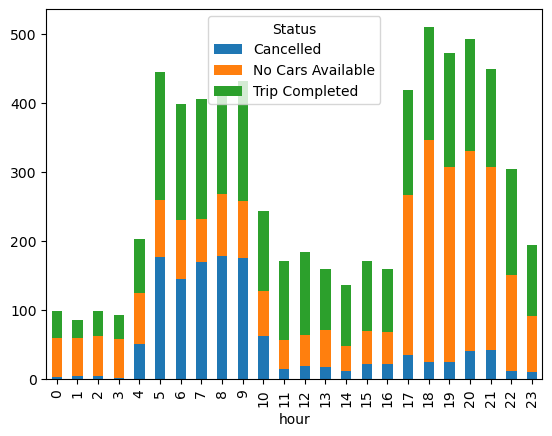

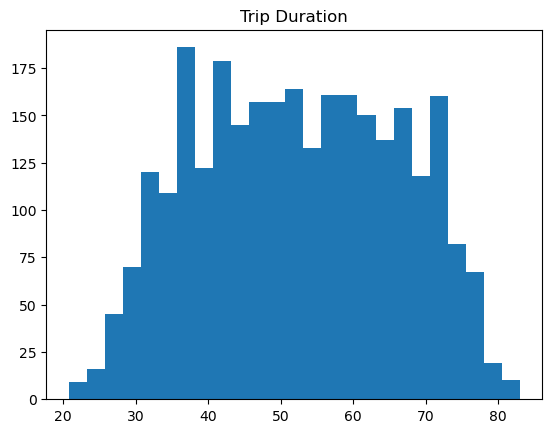

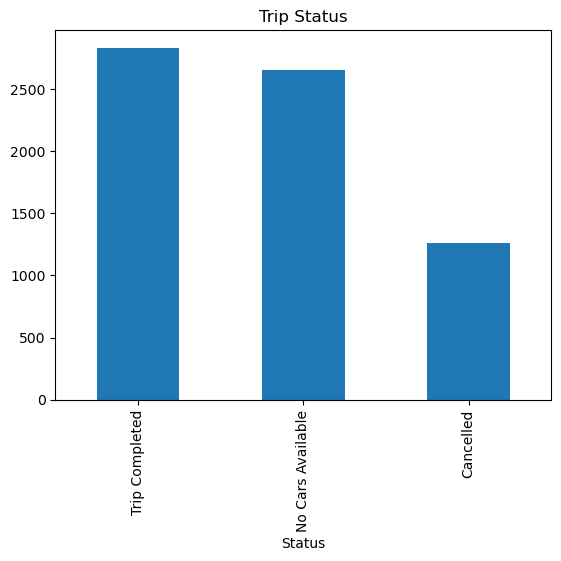

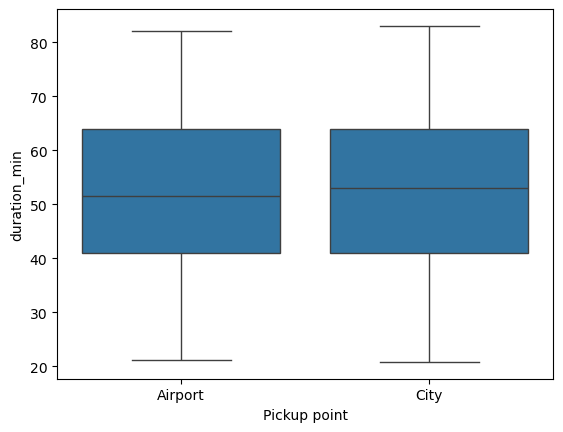

In [38]:
#histogram charts
# Hourly trips by status
hourly = df.groupby(['hour', 'Status']).size().unstack(fill_value=0)
hourly.plot(kind='bar', stacked=True)
plt.show()

# Trip duration distribution
plt.hist(completed['duration_min'], bins=25)
plt.title("Trip Duration")
plt.show()

# Status counts
df['Status'].value_counts().plot(kind='bar')
plt.title("Trip Status")
plt.show()

# Duration by pickup point
sns.boxplot(data=completed, x='Pickup point', y='duration_min')
plt.show()

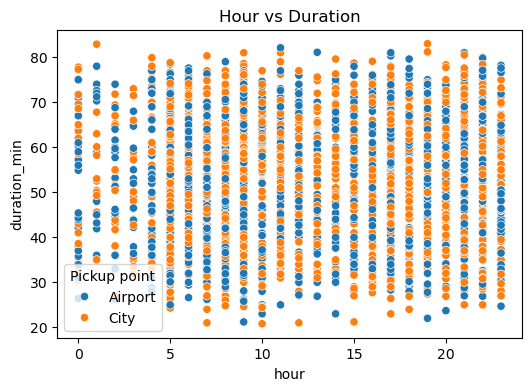

In [61]:
#scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(data=completed,
                x='hour',
                y='duration_min',
                hue='Pickup point')

plt.title("Hour vs Duration")
plt.show()

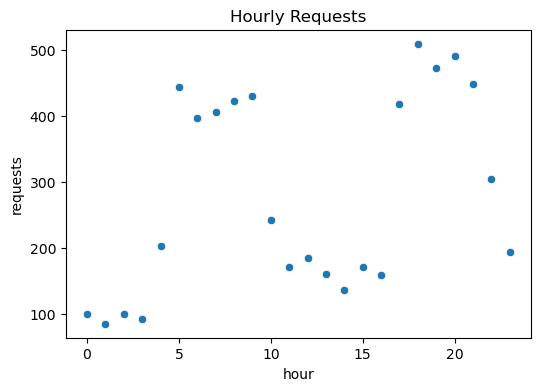

In [41]:
hourly = df.groupby('hour').size().reset_index(name='requests')

plt.figure(figsize=(6,4))
sns.scatterplot(data=hourly,
                x='hour',
                y='requests')

plt.title("Hourly Requests")
plt.show()

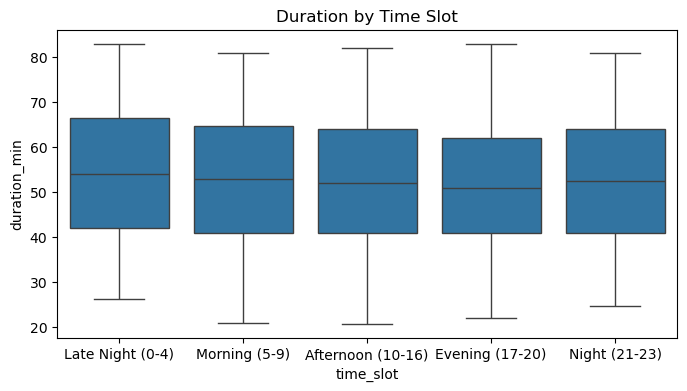

In [42]:
#timeslot
plt.figure(figsize=(8,4))
sns.boxplot(data=completed,
            x='time_slot',
            y='duration_min')

plt.title("Duration by Time Slot")
plt.show()

In [44]:
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp', 'hour', 'date', 'day_of_week',
       'duration_min', 'time_slot'],
      dtype='object')

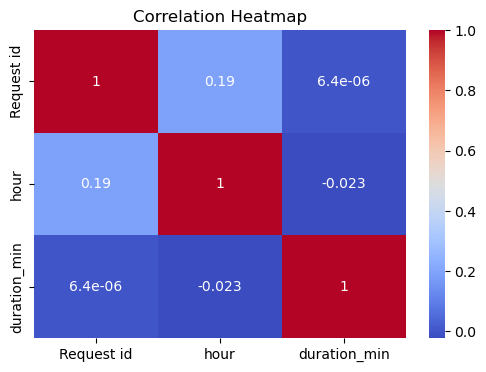

In [45]:
#heatmap
corr = df[['Request id', 'hour', 'duration_min']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

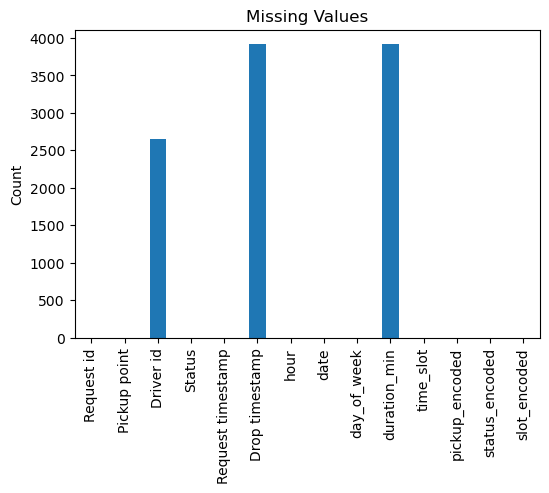

In [50]:
#checking missing values
missing = df.isnull().sum()

plt.figure(figsize=(6,4))
missing.plot(kind='bar')
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

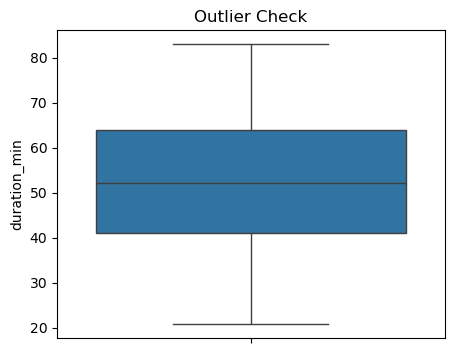

In [51]:
#outlier check
plt.figure(figsize=(5,4))
sns.boxplot(y=completed['duration_min'])
plt.title("Outlier Check")
plt.show()

In [52]:
#duplicates
df.duplicated().sum()

np.int64(0)

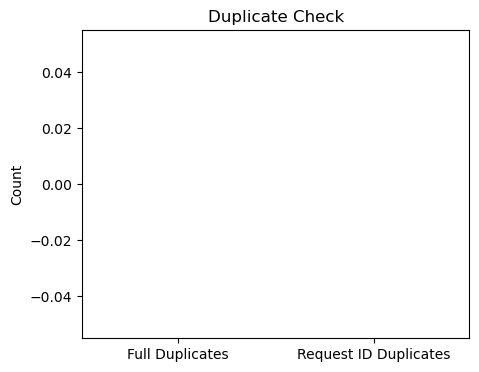

Full duplicates: 0
Request ID duplicates: 0


In [54]:
full_dupes = df.duplicated().sum()
id_dupes = df['Request id'].duplicated().sum()

plt.figure(figsize=(5,4))
plt.bar(['Full Duplicates', 'Request ID Duplicates'],
        [full_dupes, id_dupes])

plt.title('Duplicate Check')
plt.ylabel('Count')
plt.show()

print(f"Full duplicates: {full_dupes}")
print(f"Request ID duplicates: {id_dupes}")

In [55]:
checks = {
    'Invalid Pickup':
        (~df['Pickup point'].isin(['Airport','City'])).sum(),

    'Invalid Status':
        (~df['Status'].isin([
            'Trip Completed',
            'Cancelled',
            'No Cars Available'
        ])).sum(),

    'Negative Duration':
        (df['duration_min'] < 0).sum()
}

pd.Series(checks)

Invalid Pickup       0
Invalid Status       0
Negative Duration    0
dtype: int64

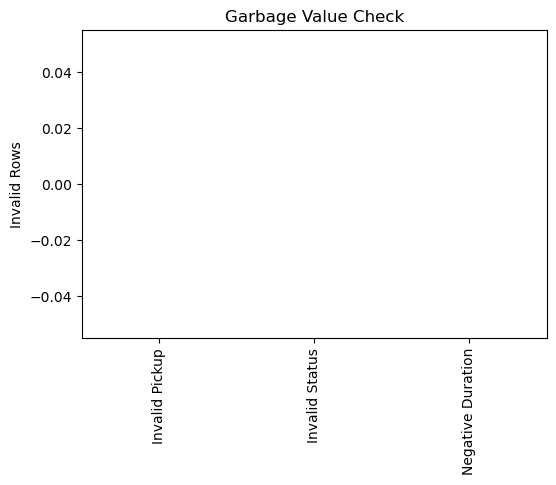

In [56]:
plt.figure(figsize=(6,4))
pd.Series(checks).plot(kind='bar')
plt.title('Garbage Value Check')
plt.ylabel('Invalid Rows')
plt.show()

In [60]:
df[['hour','duration_min',
    'hour_norm','duration_norm']].describe()

,hour,duration_min,hour_norm,duration_norm
count,6745.000000,2831.000000,6745.000000,2831.000000
mean,12.956709,52.413423,0.563335,0.508254
std,6.504052,13.850118,0.282785,0.222671
min,0.000000,20.800000,0.000000,0.000000
25%,7.000000,41.000000,0.304348,0.324759
50%,13.000000,52.100000,0.565217,0.503215
75%,19.000000,64.000000,0.826087,0.694534
max,23.000000,83.000000,1.000000,1.000000
